# Bandit Experiments

Example notebook demonstrating usage of phase 1 code in some basic experiments. 

Shows how to use existing/pre-specified agents and environments.

Note that it is possible to define your own agents and/or environments and run similar experiments.

In [1]:
import numpy as np

from ibrl.simulators import simulate
from ibrl.utils import construct_environment, construct_agent

## Configuration

Edit the lists below to choose which environments and agents to run.

In [8]:
# EG, some currently available environments (may change):
#   "bandit", "switching", "newcomb", "damascus",
#   "asymmetric-damascus", "coordination", "pdbandit"
# You can also pass options, e.g. "newcomb:transparency=0.9"

environments = [
    "bandit",
    "newcomb",
    "switching",
    "damascus",
    #"asymmetric-damascus", 
    #"coordination", 
    #"pdbandit",
]

# EG, some currently available agents (may change):
#   "classical", "bayesian", "exp3", "experimental1", "experimental2"
# You can also pass options, e.g. "classical:epsilon=0.1"

agents = [
    "classical",
    "bayesian",
    "exp3",
    "experimental1",
    "experimental2",
]

# Shared options
options = {
    "num_actions": 2,
    "num_steps":   500,
    "num_runs":    25,
    "seed":        42,
    "verbose":     0,
}

## Run experiments

In [9]:
all_results = {}

for env_name in environments:
    all_results[env_name] = {}
    for agent_name in agents:
        label = f"{env_name} / {agent_name}"
        print(f"Running: {label}")

        env = construct_environment(env_name, options)
        agent = construct_agent(agent_name, options)
        results = simulate(env, agent, options)
        all_results[env_name][agent_name] = results

        print(f"  optimal reward: {results['optimal_reward']:.4f}")
        print(f"  final avg reward: {results['average_reward'][0, -1]:.4f}")

print("Done.")

Running: bandit / classical
  optimal reward: 0.5037
  final avg reward: 0.4544
Running: bandit / bayesian
  optimal reward: 0.5037
  final avg reward: 0.4587
Running: bandit / exp3
  optimal reward: 0.5037
  final avg reward: 0.4544
Running: bandit / experimental1
  optimal reward: 0.5037
  final avg reward: 0.4147
Running: bandit / experimental2
  optimal reward: 0.5037
  final avg reward: 0.5220
Running: newcomb / classical
  optimal reward: 10.0000
  final avg reward: 6.4000
Running: newcomb / bayesian
  optimal reward: 10.0000
  final avg reward: 6.4000
Running: newcomb / exp3
  optimal reward: 10.0000
  final avg reward: 5.0000
Running: newcomb / experimental1
  optimal reward: 10.0000
  final avg reward: 9.4000
Running: newcomb / experimental2
  optimal reward: 10.0000
  final avg reward: 9.8000
Running: switching / classical
  optimal reward: 1.0000
  final avg reward: 0.9098
Running: switching / bayesian
  optimal reward: 1.0000
  final avg reward: 0.3898
Running: switching / 

## Plot results

In [10]:
from ibrl.environments import BanditEnvironment
bandit = BanditEnvironment(num_actions=2)

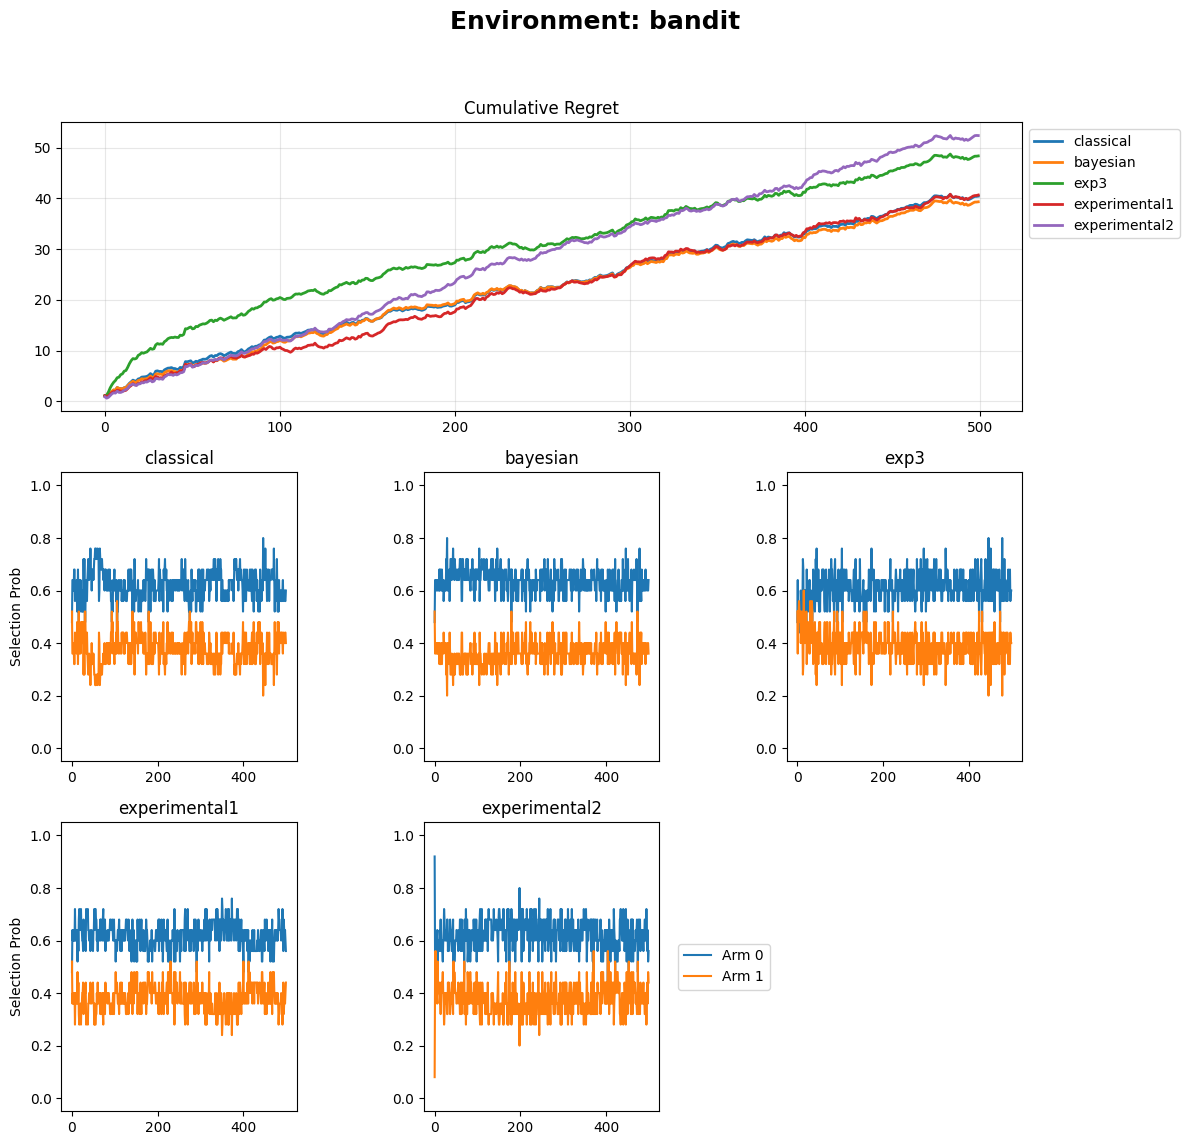

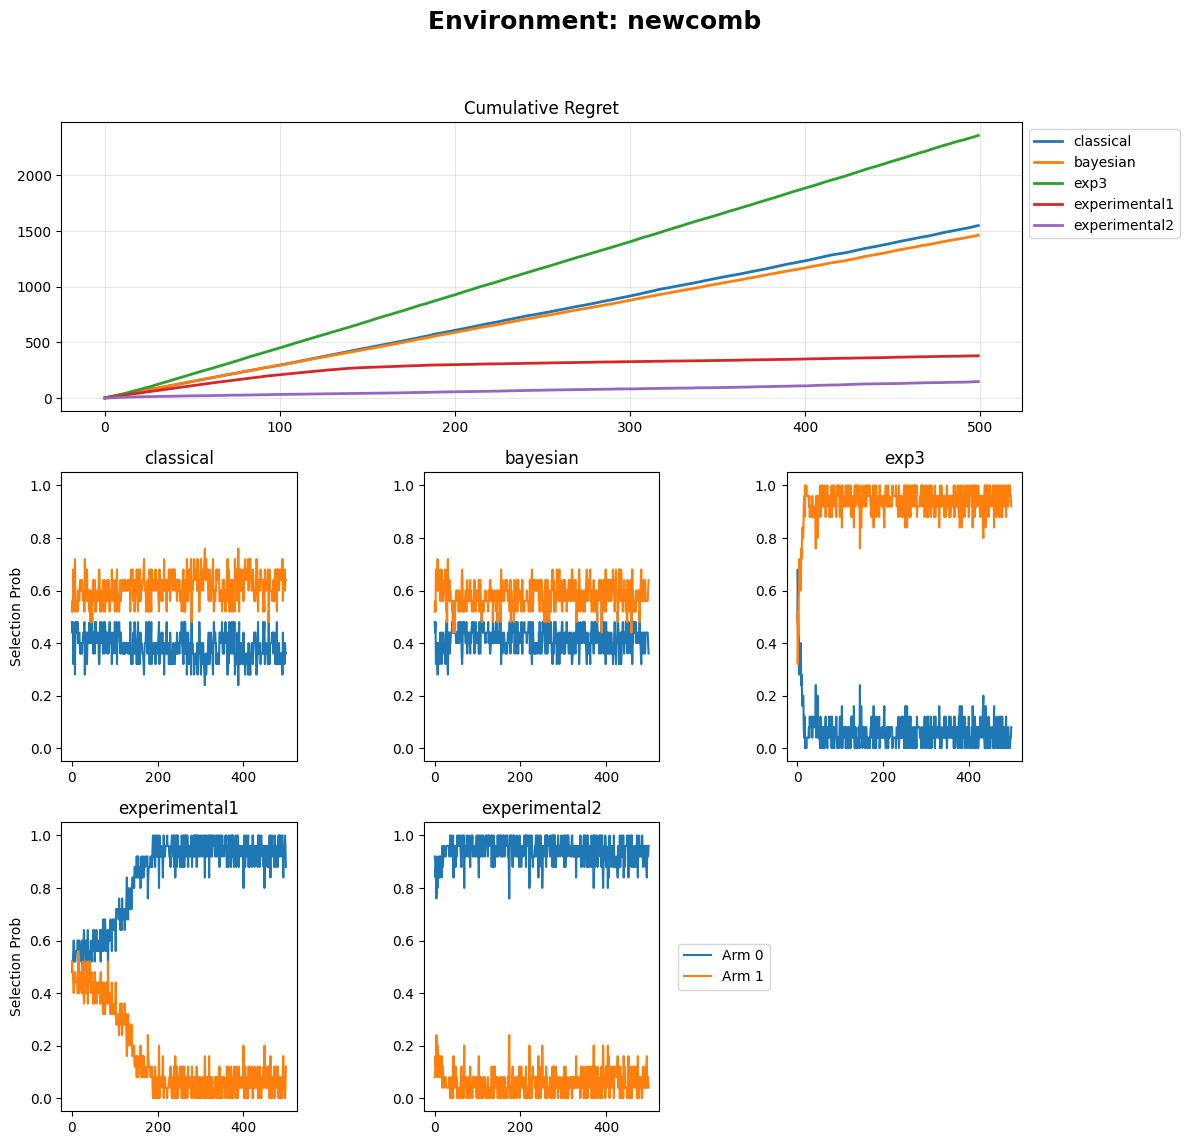

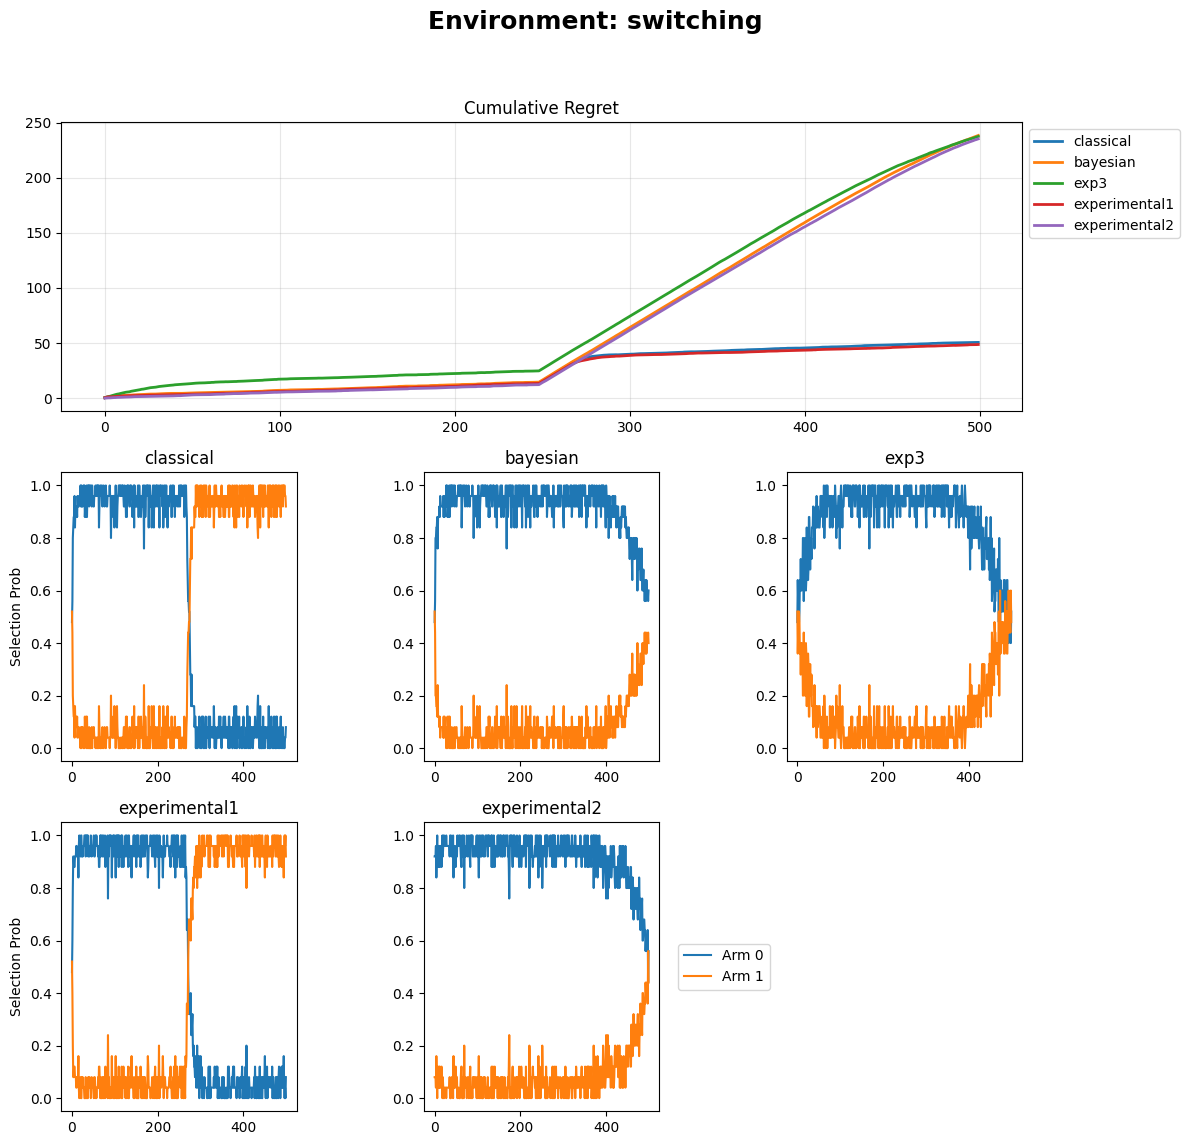

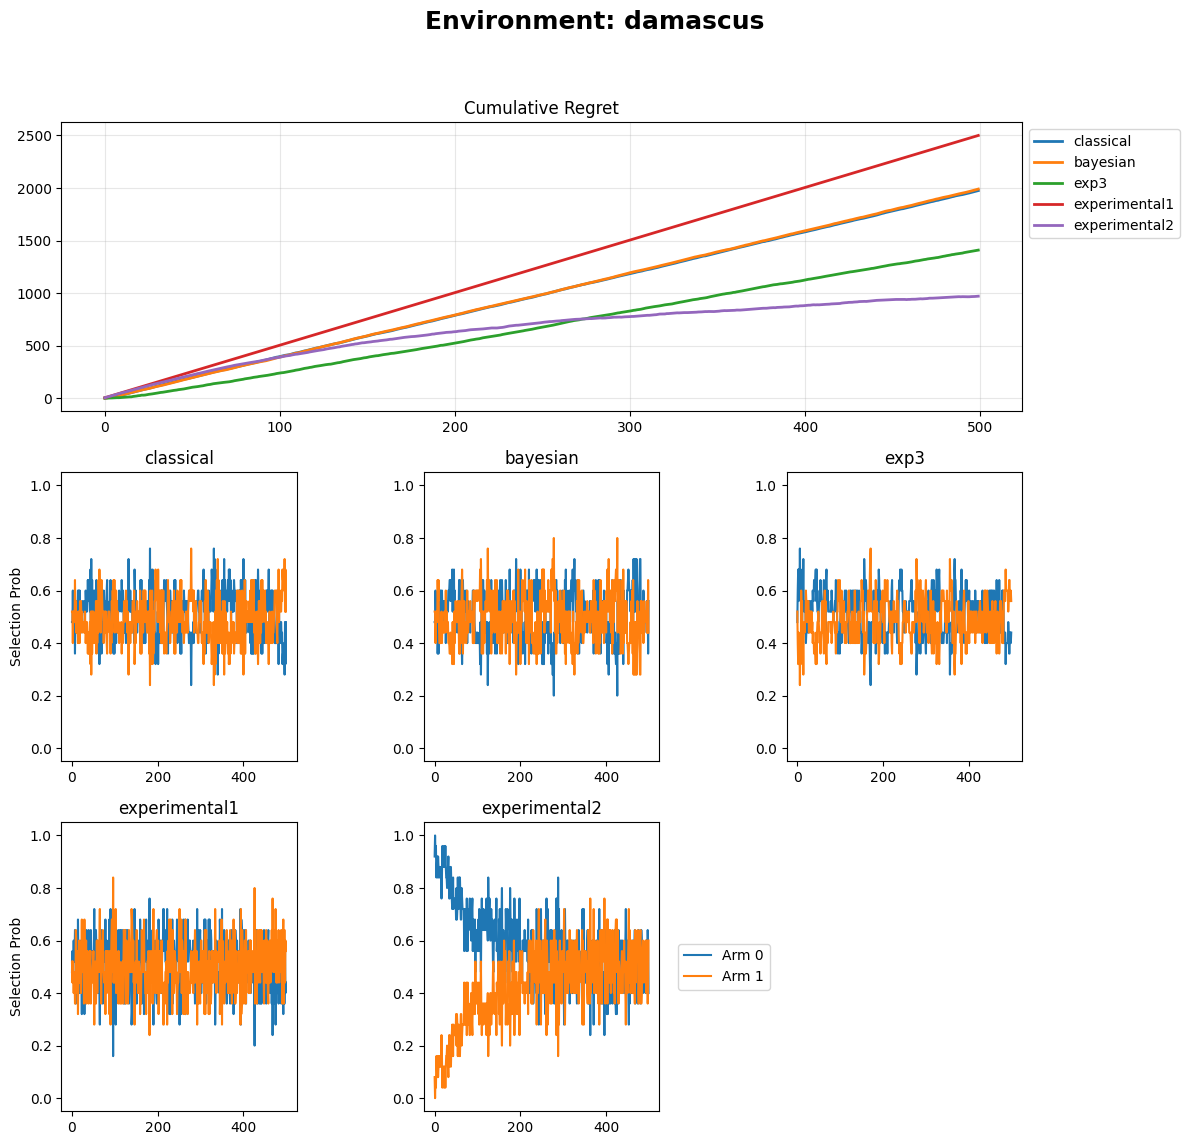

In [11]:
import math
import matplotlib.pyplot as plt

cols = 3

for env_name, agent_results in all_results.items():
    num_agents = len(agent_results)
    num_rows = math.ceil(num_agents / cols) + 1  # +1 for the regret row
    k_val = options["num_actions"]

    fig = plt.figure(figsize=(cols * 4, num_rows * 4))
    fig.suptitle(f"Environment: {env_name}", fontsize=18, fontweight='bold')

    # Top plot: Cumulative Regret (spans first row)
    ax_regret = plt.subplot(num_rows, 1, 1)
    for name, res in agent_results.items():
        avg_reward = res["average_reward"][0, :]
        optimal = res["optimal_reward"]
        cumulative_regret = np.cumsum(optimal - avg_reward)
        ax_regret.plot(cumulative_regret, label=name, linewidth=2)
    ax_regret.set_title("Cumulative Regret")
    ax_regret.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax_regret.grid(True, alpha=0.3)

    # Bottom subplots: Selection Probabilities per agent
    for i, (name, res) in enumerate(agent_results.items()):
        ax_act = plt.subplot(num_rows, cols, i + cols + 1)
        actions = res["actions"]  # (num_runs, num_steps, num_actions)
        for arm in range(k_val):
            freq = (actions == arm).mean(axis=0)
            ax_act.plot(freq, label=f"Arm {arm}")

        ax_act.set_title(f"{name}")
        ax_act.set_ylim(-0.05, 1.05)
        if i % cols == 0:
            ax_act.set_ylabel("Selection Prob")
        if i == num_agents - 1:
            ax_act.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()